# **24IT105 - Practical 1**

# **Problem Definition :**

Exploratory data analysis (EDA) for customer retention risk assessment
using telecom customer data.

A telecom company has observed a significant increase in customer attrition
over the last year. The management wants to understand customer behavior
patterns and identify factors contributing to customer churn. Before building
any predictive model, the analytics team must investigate the dataset, assess
data quality, identify hidden trends, and generate meaningful business
insights. Perform a comprehensive exploratory investigation of the customer
dataset and present findings that can help to formulate customer retention
strategies.

**Tools/Technology To Be Used:**  
* Python
* Numpy
* Pandas
* Matplotlib

Dataset : https://www.kaggle.com/datasets/blastchar/telco-customer-churn?select=WA_Fn-UseC_-Telco-Customer-Churn.csv

### **Mount Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Import required libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **Load Dataset**

In [ ]:
# Load dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/ML/Practical_01/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Fundamental Questions:**

Q1. How many observations and attributes are available?

In [ ]:
df.shape

(7043, 21)

Q2. Categorize attributes into different data types.

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Q3. Are there any missing, inconsistent, or invalid entries?

In [ ]:
# Check missing values in each column
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for blank values in TotalCharges
(df["TotalCharges"] == " ").sum()

np.int64(11)

Q4. Which attributes require preprocessing before analysis?

In [ ]:
# Check the current data types
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Q5. Identify attributes that may uniquely represent customers and justify whether they should participate in analytical modeling.

In [ ]:
# Check the number of unique values in customerID
df["customerID"].nunique()

7043

## **Data Preprocessing**

1. Convert TotalCharges to Numeric

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

2. Check Missing Values Again

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


3. Handle the Missing Values

In [ ]:
df = df.dropna()

4. Verify the Dataset

In [ ]:
# Check if missing values are removed
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


5: Verify Dataset Shape

In [ ]:
# Check updated dataset size
df.shape

(7032, 21)

## **Key Questions:**

### Q1. What is the distribution of customers across different demographic groups?

1. Gender Distribution

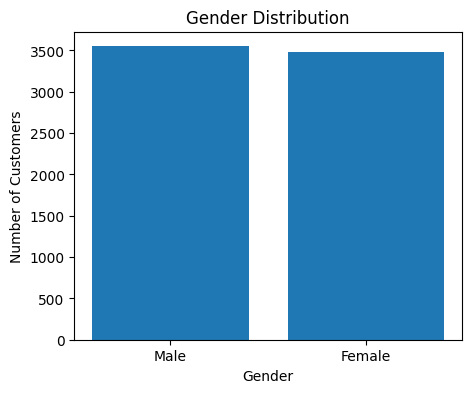

In [ ]:
# Gender distribution
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

2. Senior Citizen Distribution

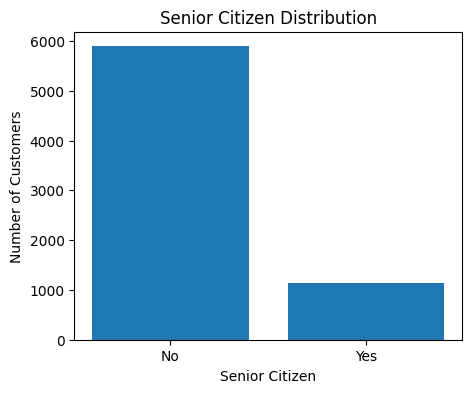

In [ ]:
# Senior Citizen distribution
senior_counts = df["SeniorCitizen"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(["No", "Yes"], senior_counts.values)
plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

3. Partner Distribution

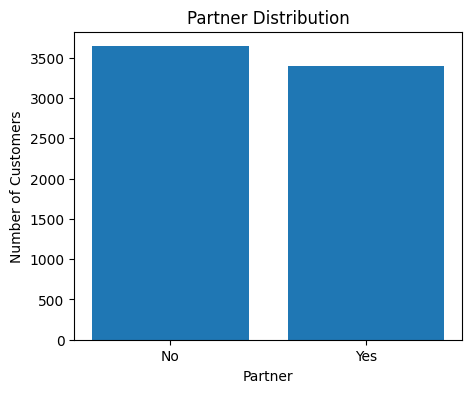

In [ ]:
# Partner distribution
partner_counts = df["Partner"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(partner_counts.index, partner_counts.values)
plt.title("Partner Distribution")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.show()

4. Dependents Distribution

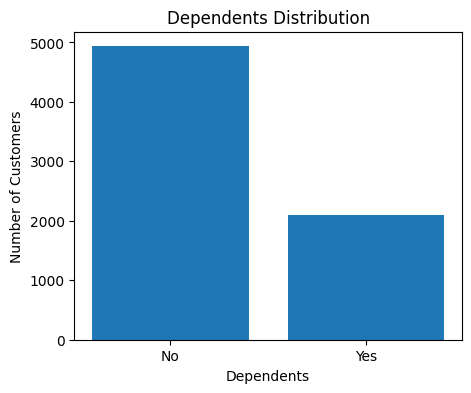

In [ ]:
# Dependents distribution
dependents_counts = df["Dependents"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(dependents_counts.index, dependents_counts.values)
plt.title("Dependents Distribution")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.show()

### Q2. Are there any dominant customer segments?

1. Contract Type

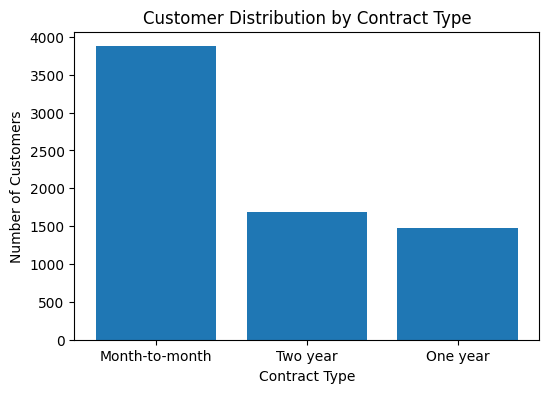

In [ ]:
# Contract type distribution
contract_counts = df["Contract"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(contract_counts.index, contract_counts.values)
plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

2. Internet Service

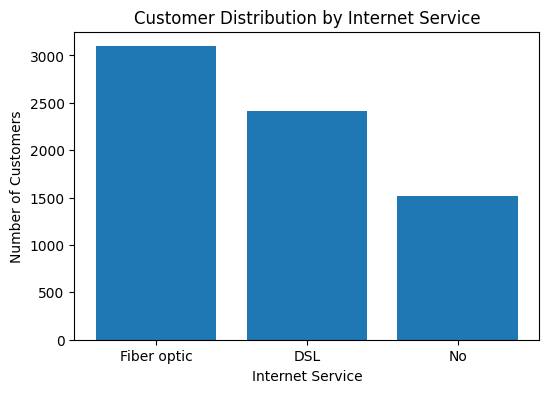

In [ ]:
# Internet service distribution
internet_counts = df["InternetService"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(internet_counts.index, internet_counts.values)
plt.title("Customer Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

3. Payment Method

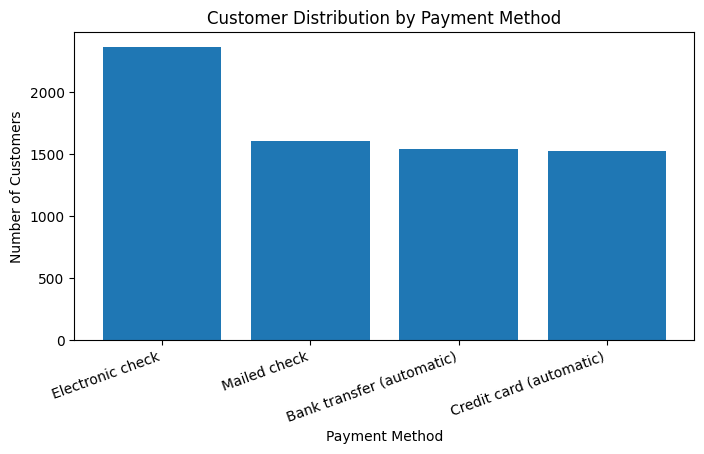

In [ ]:
# Payment method distribution
payment_counts = df["PaymentMethod"].value_counts()

plt.figure(figsize=(8,4))
plt.bar(payment_counts.index, payment_counts.values)
plt.title("Customer Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha='right')
plt.show()

### Q3. Which customer groups based on the demographic categories exhibit relatively higher attrition rates?

1. Gender vs Churn

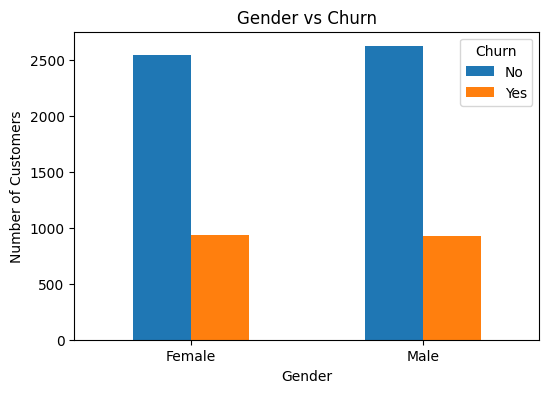

In [ ]:
# Gender vs Churn
gender_churn = pd.crosstab(df["gender"], df["Churn"])

gender_churn.plot(kind="bar", figsize=(6,4))
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

2. Senior Citizen vs Churn

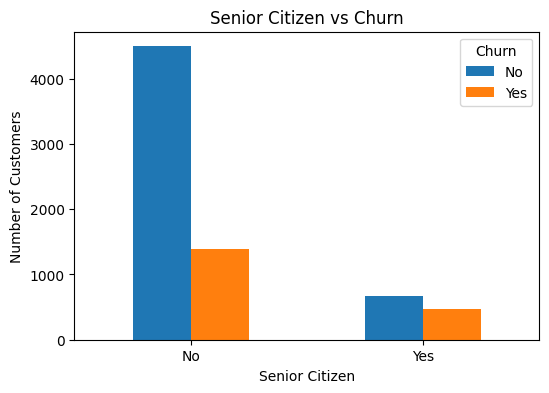

In [ ]:
# Senior Citizen vs Churn
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"])

senior_churn.index = ["No", "Yes"]

senior_churn.plot(kind="bar", figsize=(6,4))
plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

3. Partner vs Churn

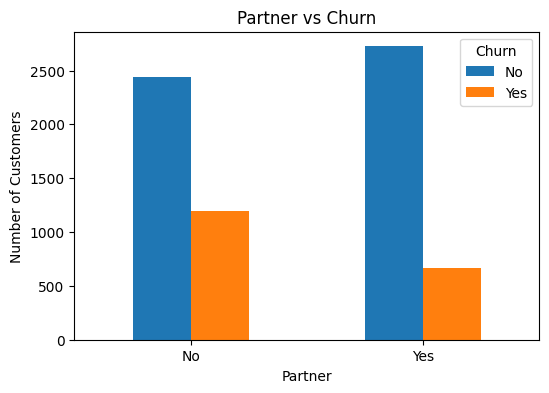

In [ ]:
# Partner vs Churn
partner_churn = pd.crosstab(df["Partner"], df["Churn"])

partner_churn.plot(kind="bar", figsize=(6,4))
plt.title("Partner vs Churn")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

4. Dependents vs Churn

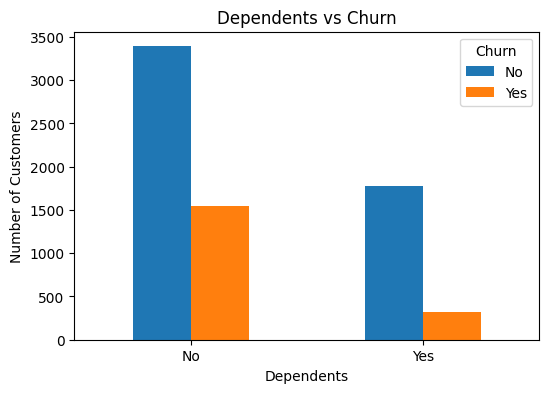

In [ ]:
# Dependents vs Churn
dependents_churn = pd.crosstab(df["Dependents"], df["Churn"])

dependents_churn.plot(kind="bar", figsize=(6,4))
plt.title("Dependents vs Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

### Q4. Which services appear strongly associated with customer retention?

1. Phone Service vs Churn

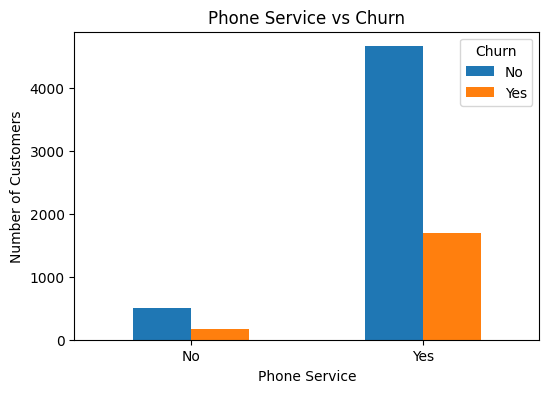

In [ ]:
# Phone Service vs Churn
phone_churn = pd.crosstab(df["PhoneService"], df["Churn"])

phone_churn.plot(kind="bar", figsize=(6,4))
plt.title("Phone Service vs Churn")
plt.xlabel("Phone Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

2. Online Security vs Churn

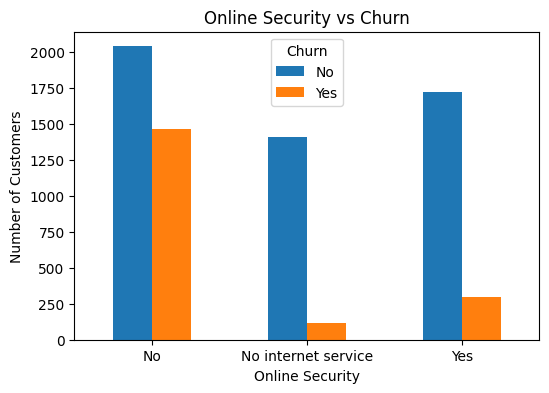

In [ ]:
# Online Security vs Churn
security_churn = pd.crosstab(df["OnlineSecurity"], df["Churn"])

security_churn.plot(kind="bar", figsize=(6,4))
plt.title("Online Security vs Churn")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

3. Tech Support vs Churn

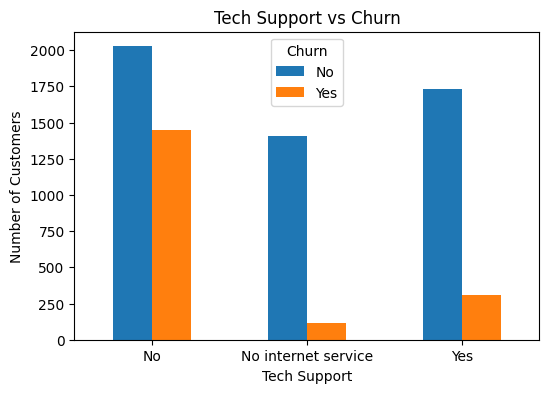

In [ ]:
# Tech Support vs Churn
tech_churn = pd.crosstab(df["TechSupport"], df["Churn"])

tech_churn.plot(kind="bar", figsize=(6,4))
plt.title("Tech Support vs Churn")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

4. Internet Service vs Churn

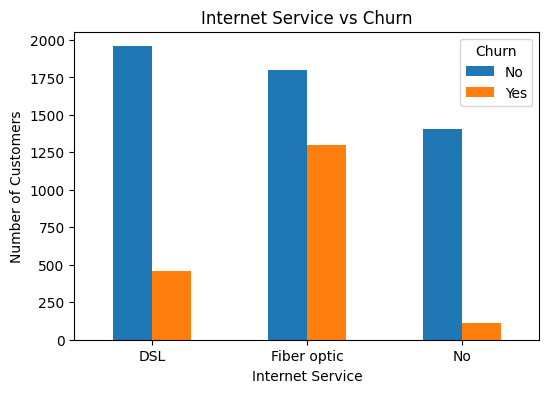

In [ ]:
# Internet Service vs Churn
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

internet_churn.plot(kind="bar", figsize=(6,4))
plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

### Q5. Which services show higher customer dissatisfaction?

1. Online Backup vs Churn

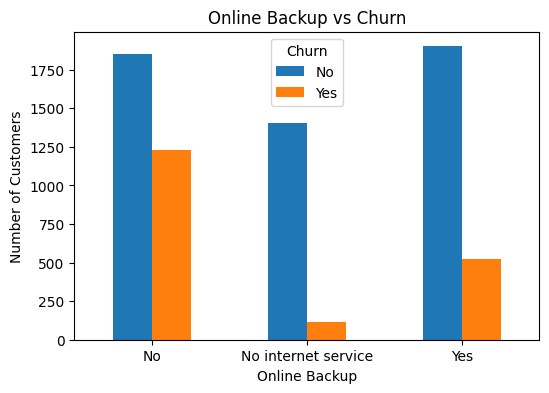

In [ ]:
# Online Backup vs Churn
backup_churn = pd.crosstab(df["OnlineBackup"], df["Churn"])

backup_churn.plot(kind="bar", figsize=(6,4))
plt.title("Online Backup vs Churn")
plt.xlabel("Online Backup")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

2. Device Protection vs Churn

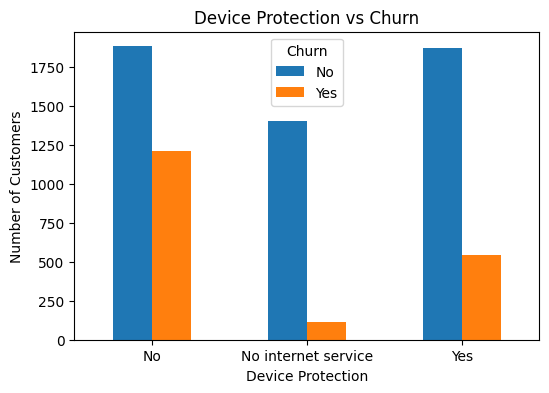

In [ ]:
# Device Protection vs Churn
device_churn = pd.crosstab(df["DeviceProtection"], df["Churn"])

device_churn.plot(kind="bar", figsize=(6,4))
plt.title("Device Protection vs Churn")
plt.xlabel("Device Protection")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

3. Streaming TV vs Churn

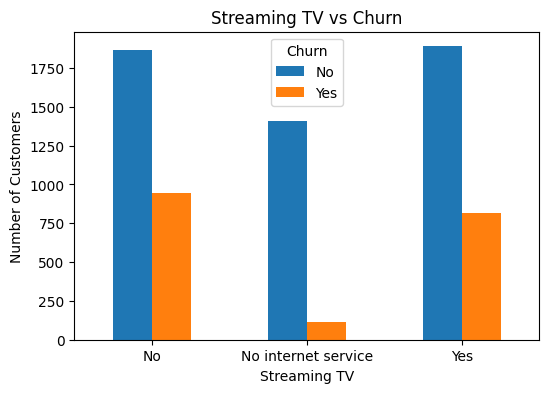

In [ ]:
# Streaming TV vs Churn
tv_churn = pd.crosstab(df["StreamingTV"], df["Churn"])

tv_churn.plot(kind="bar", figsize=(6,4))
plt.title("Streaming TV vs Churn")
plt.xlabel("Streaming TV")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

4. Streaming Movies vs Churn

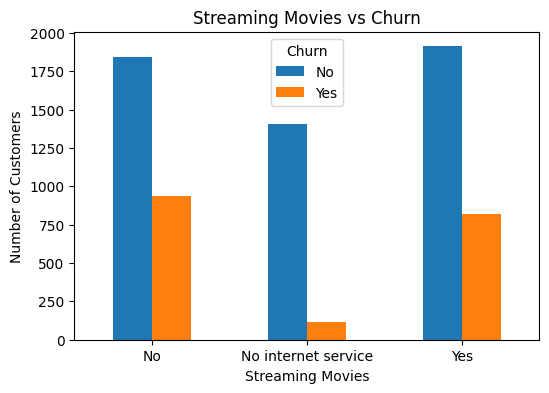

In [ ]:
# Streaming Movies vs Churn
movies_churn = pd.crosstab(df["StreamingMovies"], df["Churn"])

movies_churn.plot(kind="bar", figsize=(6,4))
plt.title("Streaming Movies vs Churn")
plt.xlabel("Streaming Movies")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

### Q6. Investigate whether customers using multiple services behave differently from those using fewer services.

Step 1: Create a Service Count Column

In [ ]:
# List of service-related columns
service_columns = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

# Count the number of active services for each customer
df["ServiceCount"] = 0

for col in service_columns:
    df["ServiceCount"] += df[col].isin(["Yes", "DSL", "Fiber optic"]).astype(int)

Step 2: Categorize Customers

In [ ]:
# Categorize customers based on the number of services
df["ServiceGroup"] = np.where(df["ServiceCount"] >= 5,
                              "Multiple Services",
                              "Fewer Services")

Step 3: Compare with Churn

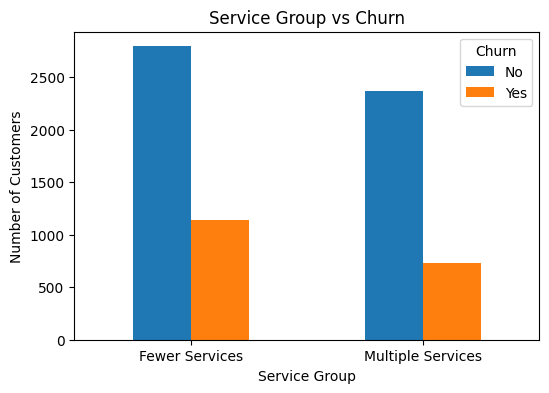

In [ ]:
# Service Group vs Churn
service_group_churn = pd.crosstab(df["ServiceGroup"], df["Churn"])

service_group_churn.plot(kind="bar", figsize=(6,4))
plt.title("Service Group vs Churn")
plt.xlabel("Service Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

### Q7. Do newly acquired customers and long-term customers exhibit different churn tendencies?

1. Histogram of Tenure

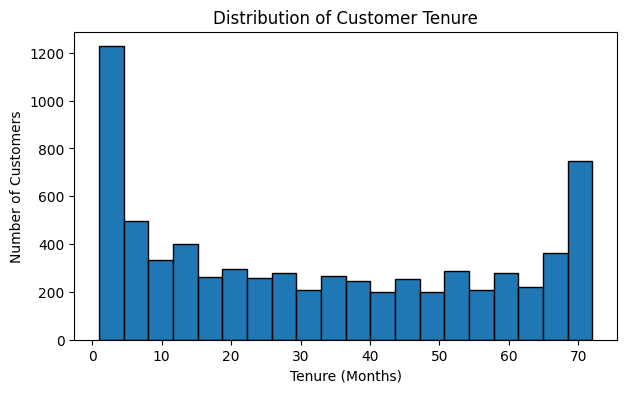

In [ ]:
# Distribution of customer tenure
plt.figure(figsize=(7,4))
plt.hist(df["tenure"], bins=20, edgecolor="black")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

2. Box Plot of Tenure by Churn

<Figure size 600x400 with 0 Axes>

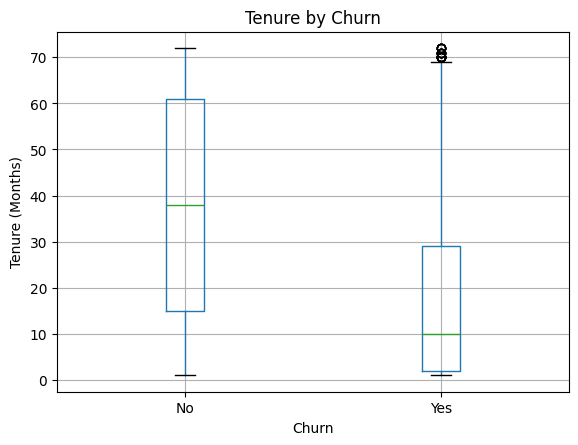

In [ ]:
# Tenure vs Churn
plt.figure(figsize=(6,4))

df.boxplot(column="tenure", by="Churn")

plt.title("Tenure by Churn")
plt.suptitle("")  # Removes the default pandas title
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

### Q8. Is the dataset balanced? Discuss potential implications of imbalance for future predictive modeling.

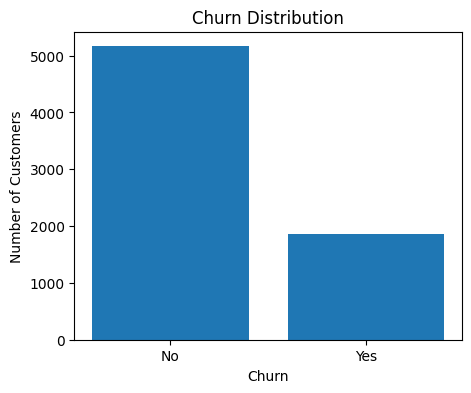

In [ ]:
# Churn distribution
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
# Number of customers in each churn category
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


### Q9. Determine the top five business observations that management should prioritize to reduce customer churn.

1. Customers with month-to-month contracts have higher churn than those with longer-term contracts.
2. Customers with shorter tenure are more likely to churn than long-term customers.
3. Customers without Online Security or Tech Support show higher churn.
4. Senior citizens tend to have a higher churn rate than non-senior citizens.
5. Customers using multiple value-added services generally show better retention than those using fewer services.

## **Supplementary Problems**

### Q1. Design a customer profile representing a high-risk churn customer.

* Month-to-month contract
* Short tenure
* Senior citizen
* No Online Security
* No Tech Support
* Uses fewer services

### Q2. Compare churn behaviour across different contract types.

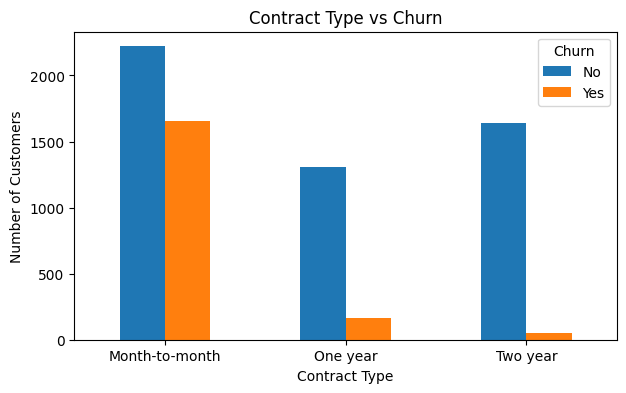

In [ ]:
# Contract Type vs Churn
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(kind="bar", figsize=(7,4))
plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

### Q3. Investigate whether senior citizens exhibit different churn patterns.

* Yes, senior citizens exhibit a different churn pattern compared to non-senior citizens. Based on the Senior Citizen vs Churn analysis, senior citizens have a relatively higher churn rate. This indicates that senior citizens are more likely to discontinue the telecom service than non-senior customers.

### Post Laboratory Analytical Report

**Key Findings**

* Dataset was cleaned by converting `TotalCharges` to numeric and removing missing values.
* Month-to-month contract customers showed higher churn.
* Customers with shorter tenure had a higher churn tendency.

**Visual Observations**

* Customers without Online Security and Tech Support had higher churn.
* Senior citizens showed relatively higher churn.
* Customers using multiple services had better retention.

**Class Imbalance**

* The dataset is slightly imbalanced, with more **No Churn** customers than **Churn** customers.

**Business Recommendations**

* Promote long-term contracts.
* Improve support services and customer engagement.
* Provide special retention offers for high-risk customers.